# AI Interview Assistant — Data Analysis, Cleaning & Model Training

This notebook covers the full ML workflow for the project:
1. Load the single dataset
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
5. Train/Test Split
6. Train & Compare 6 ML Algorithms
7. Save the Best Model + Artifacts for the Streamlit App


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from xgboost import XGBClassifier

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Dataset

This is the **single source dataset** for the whole project — it contains questions, model answers, simulated student answers, and quality labels/scores. It was generated with `build_single_dataset.py` and intentionally includes some messiness (missing values, duplicates, noisy text, invalid scores) to make the cleaning step meaningful.

In [2]:
df = pd.read_csv("interview_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (6180, 8)


,field,question,model_answer,keywords,difficulty,student_answer,score,label
0,DBMS,"In your own words, what is a foreign key?",A foreign key is a column that creates a link ...,"foreign, key, reference, link",Medium,A foreign key is a column which creates a link...,91.0,Excellent
1,Data Structures,what is a queue?,A queue is a linear data structure that follow...,"queue, fifo, linear, insertion",Medium,asdkj random text here nothing useful,19.0,Poor
2,Data Structures,"In your own words, what is recursion?",Recursion is a technique where a function call...,"recursion, function, base case, calls",Easy,asdkj random text here nothing useful,12.0,Poor
3,DBMS,Explain: What is a join in SQL?,A join is used to combine rows from two or mor...,"join, combine, tables, related",Medium,A used two or on a related column join,61.0,Average
4,Computer Networks,what is dns?,"DNS, or Domain Name System, translates human-r...","dns, domain, translate, ip",Hard,"DNS, or Domain System, human-readable domain n...",76.0,Good


## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6180 entries, 0 to 6179
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   field           6180 non-null   str    
 1   question        6180 non-null   str    
 2   model_answer    6180 non-null   str    
 3   keywords        6180 non-null   str    
 4   difficulty      6180 non-null   str    
 5   student_answer  5970 non-null   str    
 6   score           6118 non-null   float64
 7   label           6180 non-null   str    
dtypes: float64(1), str(7)
memory usage: 2.2 MB


In [4]:
df.describe(include="all")

,field,question,model_answer,keywords,difficulty,student_answer,score,label
count,6180,6180,6180,6180,6180,5970,6118.000000,6180
unique,6,1522,60,60,3,4849,NaN,4
top,Python,Briefly explain what is indexing in a database?,Thrashing occurs when a system spends most of ...,"thrashing, swapping, pages, memory",Medium,"I don't know, skip this question.",NaN,Good
freq,1034,17,109,109,2112,53,NaN,1726
mean,NaN,NaN,NaN,NaN,NaN,NaN,64.152174,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,42.169302,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,-5.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,70.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,87.000000,NaN


### 3.2 Missing Values

field               0
question            0
model_answer        0
keywords            0
difficulty          0
student_answer    210
score              62
label               0
dtype: int64


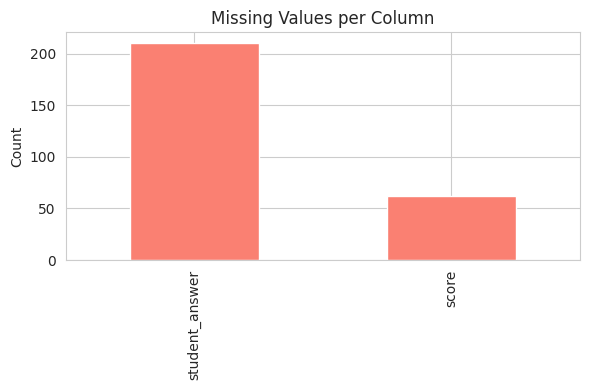

In [5]:
missing = df.isna().sum()
print(missing)

plt.figure(figsize=(6,4))
missing[missing > 0].plot(kind="bar", color="salmon")
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.3 Duplicate Rows

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 23


### 3.4 Distribution of Answer Quality Labels

/tmp/ipykernel_568/962243463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", order=["Poor","Average","Good","Excellent"], palette="viridis")


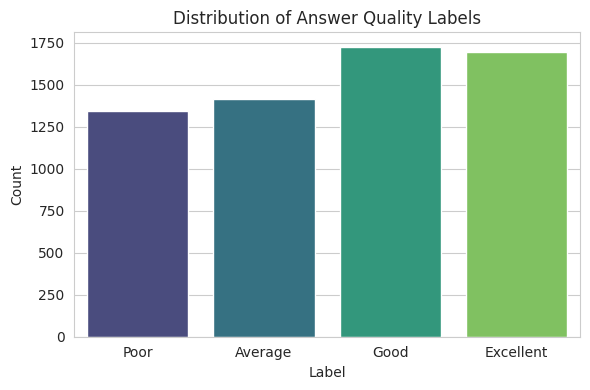

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label", order=["Poor","Average","Good","Excellent"], palette="viridis")
plt.title("Distribution of Answer Quality Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.5 Score Distribution

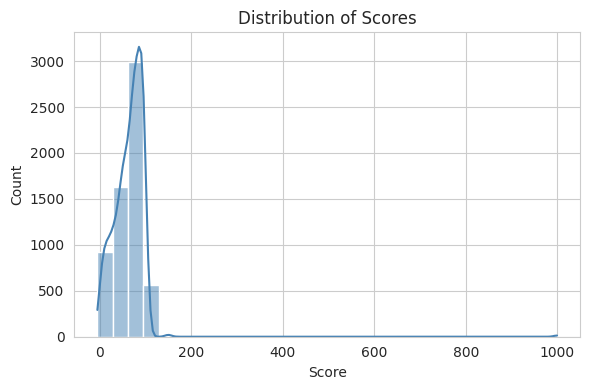

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["score"].dropna(), bins=30, kde=True, color="steelblue")
plt.title("Distribution of Scores")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

### 3.6 Questions per Field

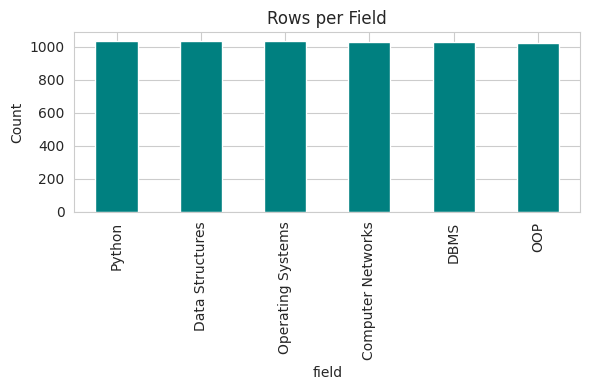

In [9]:
plt.figure(figsize=(6,4))
df["field"].value_counts().plot(kind="bar", color="teal")
plt.title("Rows per Field")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.7 Invalid / Out-of-range Scores

Scores should be between 0 and 100. Let's check for outliers that need fixing.

In [10]:
invalid_scores = df[(df["score"] < 0) | (df["score"] > 100)]
print(f"Rows with invalid scores: {len(invalid_scores)}")
invalid_scores[["question", "score"]].head()

Rows with invalid scores: 30


,question,score
189,"In your own words, what is normalization?",150.0
721,Give a short note on: what is a constructor,999.0
730,Give a short note on: what is polymorphism,150.0
1045,"In your own words, what is a queue?",150.0
1130,Briefly explain what is a linked list?,150.0


## 4. Data Cleaning

Steps:
1. Drop rows with missing `student_answer` or `score`
2. Remove duplicate rows
3. Clip out-of-range scores to [0, 100]
4. Normalize text (strip whitespace, collapse multiple spaces, fix repeated punctuation)
5. Recompute the `label` from the cleaned score
6. Drop any newly-created duplicates after normalization

In [11]:
print("BEFORE CLEANING")
print("Shape:", df.shape)
print("Missing values:\n", df.isna().sum())
print("Duplicates:", df.duplicated().sum())
print("Score range:", df["score"].min(), "-", df["score"].max())

BEFORE CLEANING
Shape: (6180, 8)
Missing values:
 field               0
question            0
model_answer        0
keywords            0
difficulty          0
student_answer    210
score              62
label               0
dtype: int64
Duplicates: 23
Score range: -5.0 - 999.0


In [12]:
def score_to_label(score):
    if score >= 85:
        return "Excellent"
    elif score >= 65:
        return "Good"
    elif score >= 40:
        return "Average"
    return "Poor"

def normalize_text(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"\.{2,}", ".", x)
    return x

df_clean = df.dropna(subset=["student_answer", "score"]).copy()
df_clean = df_clean.drop_duplicates()
df_clean["score"] = df_clean["score"].clip(lower=0, upper=100)
df_clean["student_answer"] = df_clean["student_answer"].apply(normalize_text)
df_clean["question"] = df_clean["question"].apply(normalize_text)
df_clean = df_clean[df_clean["student_answer"].str.len() > 0]
df_clean["label"] = df_clean["score"].apply(score_to_label)
df_clean = df_clean.drop_duplicates(subset=["question", "student_answer", "score"])
df_clean = df_clean.reset_index(drop=True)

In [13]:
print("AFTER CLEANING")
print("Shape:", df_clean.shape)
print("Missing values:\n", df_clean.isna().sum())
print("Duplicates:", df_clean.duplicated().sum())
print("Score range:", df_clean["score"].min(), "-", df_clean["score"].max())
print("\nLabel distribution:\n", df_clean["label"].value_counts())

AFTER CLEANING
Shape: (5806, 8)
Missing values:
 field             0
question          0
model_answer      0
keywords          0
difficulty        0
student_answer    0
score             0
label             0
dtype: int64
Duplicates: 0
Score range: 0.0 - 100.0



Label distribution:
 label
Good         1646
Excellent    1631
Average      1346
Poor         1183
Name: count, dtype: int64


### Cleaned Label Distribution (visual check)

/tmp/ipykernel_568/2179539768.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="label", order=["Poor","Average","Good","Excellent"], palette="crest")


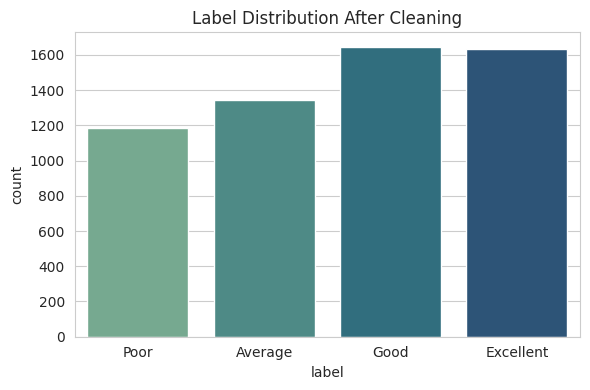

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="label", order=["Poor","Average","Good","Excellent"], palette="crest")
plt.title("Label Distribution After Cleaning")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

We convert each `(model_answer, student_answer)` pair into 5 numeric features:
- **tfidf_cosine_sim** — TF-IDF cosine similarity between the two texts
- **jaccard_sim** — word-overlap similarity (intersection / union)
- **keyword_overlap** — fraction of expected keywords present in the student answer
- **length_ratio** — student answer length ÷ model answer length
- **word_count** — word count of the student answer

In [15]:
def tokenize(text):
    return set(re.findall(r"[a-z]+", str(text).lower()))

vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
vectorizer.fit(df_clean["model_answer"].tolist() + df_clean["student_answer"].tolist())

tfidf_cosine_sim, jaccard_sim, keyword_overlap, length_ratio, word_count = [], [], [], [], []

for _, row in df_clean.iterrows():
    m_ans, s_ans, kws = row["model_answer"], row["student_answer"], row["keywords"]

    m_vec = vectorizer.transform([m_ans])
    s_vec = vectorizer.transform([s_ans])
    tfidf_cosine_sim.append(cosine_similarity(m_vec, s_vec)[0][0])

    m_tok, s_tok = tokenize(m_ans), tokenize(s_ans)
    union = m_tok | s_tok
    jaccard_sim.append(len(m_tok & s_tok) / len(union) if union else 0.0)

    kw_list = [k.strip().lower() for k in kws.split(",") if k.strip()]
    s_lower = s_ans.lower()
    keyword_overlap.append(sum(1 for k in kw_list if k in s_lower) / len(kw_list) if kw_list else 0.0)

    m_len = max(1, len(m_ans.split()))
    s_len = len(s_ans.split())
    length_ratio.append(min(s_len / m_len, 3.0))
    word_count.append(s_len)

features = pd.DataFrame({
    "tfidf_cosine_sim": tfidf_cosine_sim,
    "jaccard_sim": jaccard_sim,
    "keyword_overlap": keyword_overlap,
    "length_ratio": length_ratio,
    "word_count": word_count,
})
features["label"] = df_clean["label"].values
features["score"] = df_clean["score"].values
features.head()

,tfidf_cosine_sim,jaccard_sim,keyword_overlap,length_ratio,word_count,label,score
0,1.000000,0.894737,0.75,1.000000,21,Excellent,91.0
1,0.000000,0.000000,0.00,0.230769,6,Poor,19.0
2,0.000000,0.000000,0.00,0.260870,6,Poor,12.0
3,0.702192,0.444444,0.50,0.473684,9,Average,61.0
4,0.960540,0.842105,0.75,0.842105,16,Good,76.0


### Sanity Check: Do Features Correlate with Score?

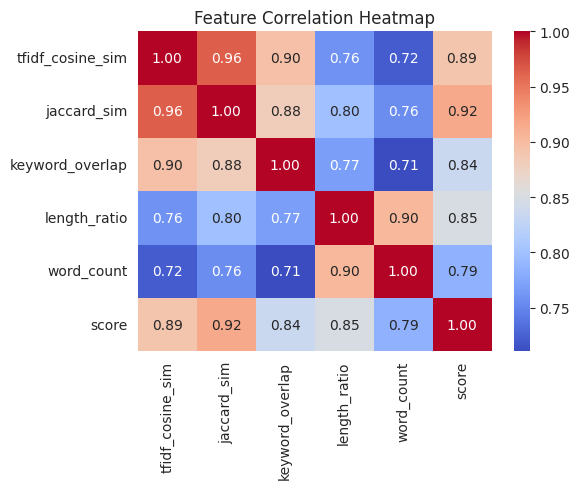

In [16]:
plt.figure(figsize=(6,5))
sns.heatmap(features[["tfidf_cosine_sim","jaccard_sim","keyword_overlap","length_ratio","word_count","score"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6. Train/Test Split

In [17]:
FEATURE_COLS = ["tfidf_cosine_sim", "jaccard_sim", "keyword_overlap", "length_ratio", "word_count"]

X = features[FEATURE_COLS].values
y = features["label"].values

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (4644, 5)
Test shape: (1162, 5)


## 7. Train & Compare 6 ML Algorithms

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              eval_metric="mlogloss", random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")
    precision = precision_score(y_test, preds, average="weighted", zero_division=0)
    recall = recall_score(y_test, preds, average="weighted")

    results.append({"Model": name, "Accuracy": round(acc*100,2), "F1_Score": round(f1*100,2),
                     "Precision": round(precision*100,2), "Recall": round(recall*100,2)})
    trained_models[name] = model
    print(f"{name:22s} | Accuracy: {acc*100:6.2f}% | F1: {f1*100:6.2f}%")

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

Logistic Regression    | Accuracy:  76.25% | F1:  75.87%


Random Forest          | Accuracy:  77.80% | F1:  77.80%


SVM                    | Accuracy:  80.12% | F1:  79.99%
Naive Bayes            | Accuracy:  72.81% | F1:  72.05%
KNN                    | Accuracy:  79.00% | F1:  78.88%


XGBoost                | Accuracy:  79.60% | F1:  79.57%


,Model,Accuracy,F1_Score,Precision,Recall
0,SVM,80.12,79.99,80.71,80.12
1,XGBoost,79.60,79.57,80.43,79.60
2,KNN,79.00,78.88,79.19,79.00
3,Random Forest,77.80,77.80,78.17,77.80
4,Logistic Regression,76.25,75.87,75.92,76.25
5,Naive Bayes,72.81,72.05,71.99,72.81


### Accuracy Comparison Chart

/tmp/ipykernel_568/3192624890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Model", palette="mako")


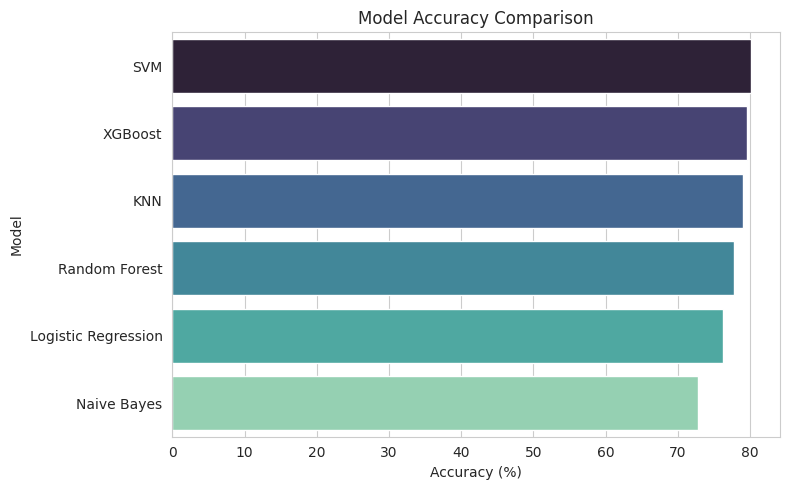

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="mako")
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy (%)")
plt.tight_layout()
plt.show()

### Best Model + Confusion Matrix

Best model: SVM (80.12% accuracy)


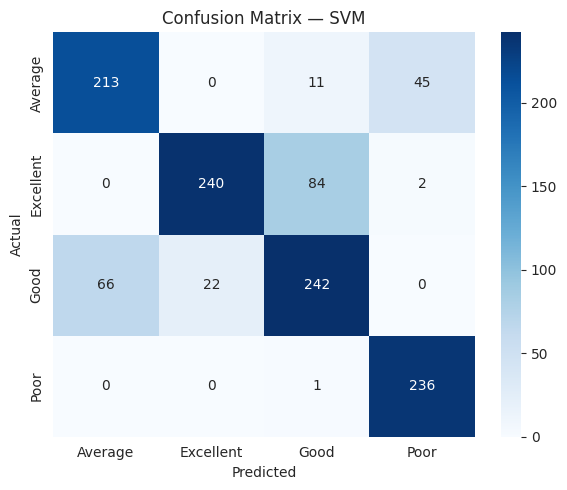

In [20]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name} ({results_df.iloc[0]['Accuracy']}% accuracy)")

preds = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. Save Model Artifacts for the Streamlit App

These `.pkl` files and the cleaned dataset are what `app.py` loads at runtime. No retraining happens inside the app — it just loads what we saved here.

In [21]:
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
with open("best_model_name.txt", "w") as f:
    f.write(best_model_name)

results_df.to_csv("model_comparison.csv", index=False)

df_clean.to_csv("interview_dataset_clean.csv", index=False)

print("Saved all model artifacts to models/")
print("Saved cleaned dataset to interview_dataset_clean.csv")

Saved all model artifacts to models/
Saved cleaned dataset to interview_dataset_clean.csv


## Summary

- Loaded a single raw dataset (`data/interview_dataset.csv`)
- Performed EDA: missing values, duplicates, label/score distributions, correlations
- Cleaned the data: dropped nulls, removed duplicates, fixed invalid scores, normalized text
- Engineered 5 similarity/overlap features from the text pairs
- Trained and compared 6 ML algorithms, selected the best by accuracy
- Saved the trained model + preprocessing objects for deployment in `app.py`